In [1]:
# !pip install tensorflow

In [2]:
import numpy as np
import pandas as pd

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [4]:
data = pd.read_csv("Iris.csv", index_col="Id")
data.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
Id,,,,,
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
X = data.drop("Species", axis=1).to_numpy()
y = data[["Species"]].to_numpy()

In [6]:
scaler = StandardScaler()
onehot_encoder = OneHotEncoder(sparse_output=False)

enc_y = onehot_encoder.fit_transform(y)
scaled_X = scaler.fit_transform(X)

In [8]:
cat_array = onehot_encoder.categories_[0]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    scaled_X, enc_y, test_size=0.2, shuffle=True, stratify=enc_y, random_state=999
)

## Model Creation and Compile

In [66]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import SGD, Adam

In [67]:
inp_shape = X_train.shape[1]
num_classes = y_train.shape[1]

In [68]:
model = Sequential()

model.add(Input(shape = (inp_shape,))) #< Input Layer

model.add(Dense(10, activation="relu")) #< Hidden Layer
model.add(Dense(6, activation="relu")) #< Hidden Layer

model.add(Dense(num_classes, activation="softmax")) #< Output Layer

model.compile(
    optimizer=Adam(learning_rate=0.1), loss = "categorical_crossentropy", metrics=["accuracy"]
)

In [69]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 6)              │            66 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 3)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 137 (548.00 B)

 Trainable params: 137 (548.00 B)

 Non-trainable params: 0 (0.00 B)

In [70]:
history = model.fit(
    X_train, y_train, epochs=50, batch_size=64, verbose=1,
)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4083 - loss: 0.9732 
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6667 - loss: 0.6379
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7333 - loss: 0.4503
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6750 - loss: 0.4929
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8167 - loss: 0.3558
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8750 - loss: 0.3114
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8917 - loss: 0.2646
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9000 - loss: 0.2299
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8833 - loss: 0.2197
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9083 - loss: 0.1712
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9500 - loss: 0.1358
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9583 - loss: 0.1174


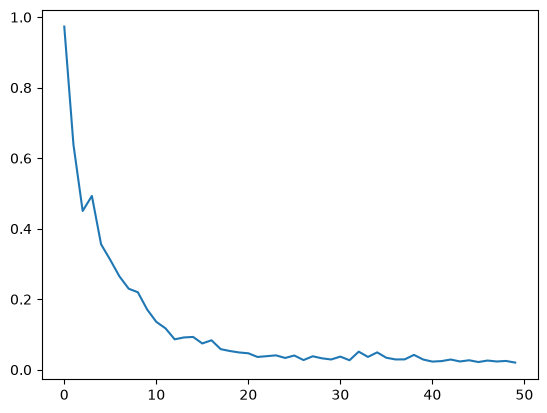

In [71]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"])

In [72]:
loss, accuracy = model.evaluate(X_test, y_test)
accuracy

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9667 - loss: 0.1877


0.9666666388511658

In [73]:
y_pred = np.argmax(model.predict(X_test), axis = 1)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


array([2, 2, 2, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 2, 2, 1, 1, 0, 1, 2,
       1, 2, 0, 1, 2, 1, 0, 2])

In [74]:
y_true = np.argmax(y_test,  axis = 1)
y_true

array([2, 2, 2, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 2, 1, 2, 2, 1, 1, 0, 1, 2,
       1, 2, 0, 1, 2, 1, 0, 2])

In [75]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

In [76]:
confusion_matrix(y_true, y_pred)

array([[10,  0,  0],
       [ 0, 10,  0],
       [ 0,  1,  9]])

In [77]:
accuracy_score(y_true, y_pred)

0.9666666666666667

In [78]:
recall_score(y_true, y_pred, average = "weighted")

0.9666666666666667

In [62]:
f1_score(y_true, y_pred, average = "macro")

0.9665831244778613

In [83]:
cat_array[np.argmax(model.predict(
    np.array([[5.1, 3.5, 1.4, 0.2]])
))]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


'Iris-versicolor'

In [88]:
model.save("iris_classifier.keras")

In [87]:
import pickle # joblib

In [90]:
to_package = {
    "scaler" : scaler,
    "encoder" : onehot_encoder,
    "model" : model
}

with open("iris_classifier.pkl", "wb") as file:
    pickle.dump(to_package, file)